# Lab I: Multi-View VAE for MNIST and SVHN

**Authors:** Alfredo Estirado Cubero, [Student 2], [Student 3]

**Date:** October 2026

---

## Goal

We build a *multi-view variational autoencoder* (MV-VAE) that learns a **shared latent space** for two image domains:
- **MNIST** – handwritten grey-scale digits, 28×28 → resized to 32×32.
- **SVHN**  – Street View House Numbers, colour 32×32.

Every training sample is a **pair** (MNIST image, SVHN image) of the **same digit** (0–9).
After training the model can:
1. Reconstruct each view from a joint or single-view encoding.
2. Sample new digits from the prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$.
3. Do **cross-domain generation**: MNIST → SVHN and SVHN → MNIST.

The architecture follows the CelebA reference closely (conv encoder/decoder, softplus variance,
Gaussian ELBO with fixed $\sigma_x$) and extends it to two views via a **Product of Experts** joint posterior.

## 1. Imports and Setup

In [1]:
import os, random, time
import numpy as np
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)

torch: 2.11.0+cu130 | torchvision: 0.26.0+cu130


In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR       = "/content/data"
CHECKPOINT_DIR = "/content/checkpoints"
FIGURES_DIR    = "/content/figures"

for d in [DATA_DIR, CHECKPOINT_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "mvvae.pth")

Using device: cuda


## 2. Paired MNIST–SVHN Dataset

### How the pairing works

A multi-view VAE needs aligned data: each sample must contain one MNIST image and
one SVHN image with the **same digit label**.  We build this pairing:

1. Download MNIST and SVHN with `torchvision`.
2. Group each dataset by label (0–9).
3. For each class shuffle both lists independently, then pair index-by-index
   up to `min(n_mnist, n_svhn)` pairs.

This means some images are unused (SVHN has more examples per class than MNIST for most digits).
The pairing is deterministic given the seed.

**Transforms:**
- MNIST: resize 28×28 → 32×32, `ToTensor`, normalise to $[-1, 1]$ (1 channel).
- SVHN: `ToTensor`, normalise to $[-1, 1]$ (3 channels, already 32×32).

> *`torchvision ≥ 0.9` maps SVHN label 10 → 0 automatically.*

In [3]:
class PairedMNISTSVHN(Dataset):
    '''Each item: (x_mnist [1,32,32], x_svhn [3,32,32], label int).
    Both tensors are float32 in [-1, 1].'''
    IMG_SIZE = 32

    def __init__(self, root, split='train', seed=42):
        assert split in ('train', 'test')
        mnist_tf = T.Compose([
            T.Resize(self.IMG_SIZE),
            T.ToTensor(),
            T.Normalize((0.5,), (0.5,)),
        ])
        svhn_tf = T.Compose([
            T.ToTensor(),
            T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        self.mnist_ds = datasets.MNIST(root, train=(split == 'train'),
                                       download=True, transform=mnist_tf)
        self.svhn_ds  = datasets.SVHN(root,  split=split,
                                       download=True, transform=svhn_tf)

        rng           = np.random.RandomState(seed)
        mnist_targets = np.array(self.mnist_ds.targets)
        svhn_targets  = self.svhn_ds.labels          # already 0-9

        self.pairs = []
        for c in range(10):
            m_ids = np.where(mnist_targets == c)[0].copy()
            s_ids = np.where(svhn_targets  == c)[0].copy()
            # pair up to the smaller class size; excess images are discarded
            n = min(len(m_ids), len(s_ids))
            rng.shuffle(m_ids); rng.shuffle(s_ids)
            for i in range(n):
                self.pairs.append((int(m_ids[i]), int(s_ids[i]), c))
        # mix pairs across class boundaries so batches are not class-sorted
        rng.shuffle(self.pairs)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        m_idx, s_idx, label = self.pairs[idx]
        x_m, _ = self.mnist_ds[m_idx]
        x_s, _ = self.svhn_ds[s_idx]
        return x_m, x_s, label

In [4]:
BATCH_SIZE = 128
# MAX_TRAIN_PAIRS: cap training set size for CPU speed (~35 min for 30 epochs).
# Set to None to use all ~60 k pairs (recommended on GPU / Colab).
MAX_TRAIN_PAIRS = 12_000

train_set = PairedMNISTSVHN(DATA_DIR, split='train', seed=SEED)
test_set  = PairedMNISTSVHN(DATA_DIR, split='test',  seed=SEED)

if MAX_TRAIN_PAIRS is not None:
    train_set.pairs = train_set.pairs[:MAX_TRAIN_PAIRS]

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(device.type == 'cuda'))
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(device.type == 'cuda'))

print(f"Train pairs : {len(train_set):,}")
print(f"Test  pairs : {len(test_set):,}")

# Sanity check: label in pair must match both datasets
for m_idx, s_idx, c in train_set.pairs[:500]:
    assert int(train_set.mnist_ds.targets[m_idx]) == c
    assert int(train_set.svhn_ds.labels[s_idx])   == c
print("Label-match assertion passed (first 500 pairs).")

x_m_batch, x_s_batch, lbl_batch = next(iter(train_loader))
print(f"MNIST batch : {x_m_batch.shape}, range [{x_m_batch.min():.2f}, {x_m_batch.max():.2f}]")
print(f"SVHN  batch : {x_s_batch.shape}, range [{x_s_batch.min():.2f}, {x_s_batch.max():.2f}]")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.25MB/s]
100%|██████████| 182M/182M [00:04<00:00, 41.6MB/s]
/tmp/ipykernel_3414/2278353254.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mnist_targets = np.array(self.mnist_ds.targets)
100%|██████████| 64.3M/64.3M [00:02<00:00, 22.3MB/s]


Train pairs : 12,000
Test  pairs : 10,000
Label-match assertion passed (first 500 pairs).
MNIST batch : torch.Size([128, 1, 32, 32]), range [-1.00, 1.00]
SVHN  batch : torch.Size([128, 3, 32, 32]), range [-1.00, 1.00]


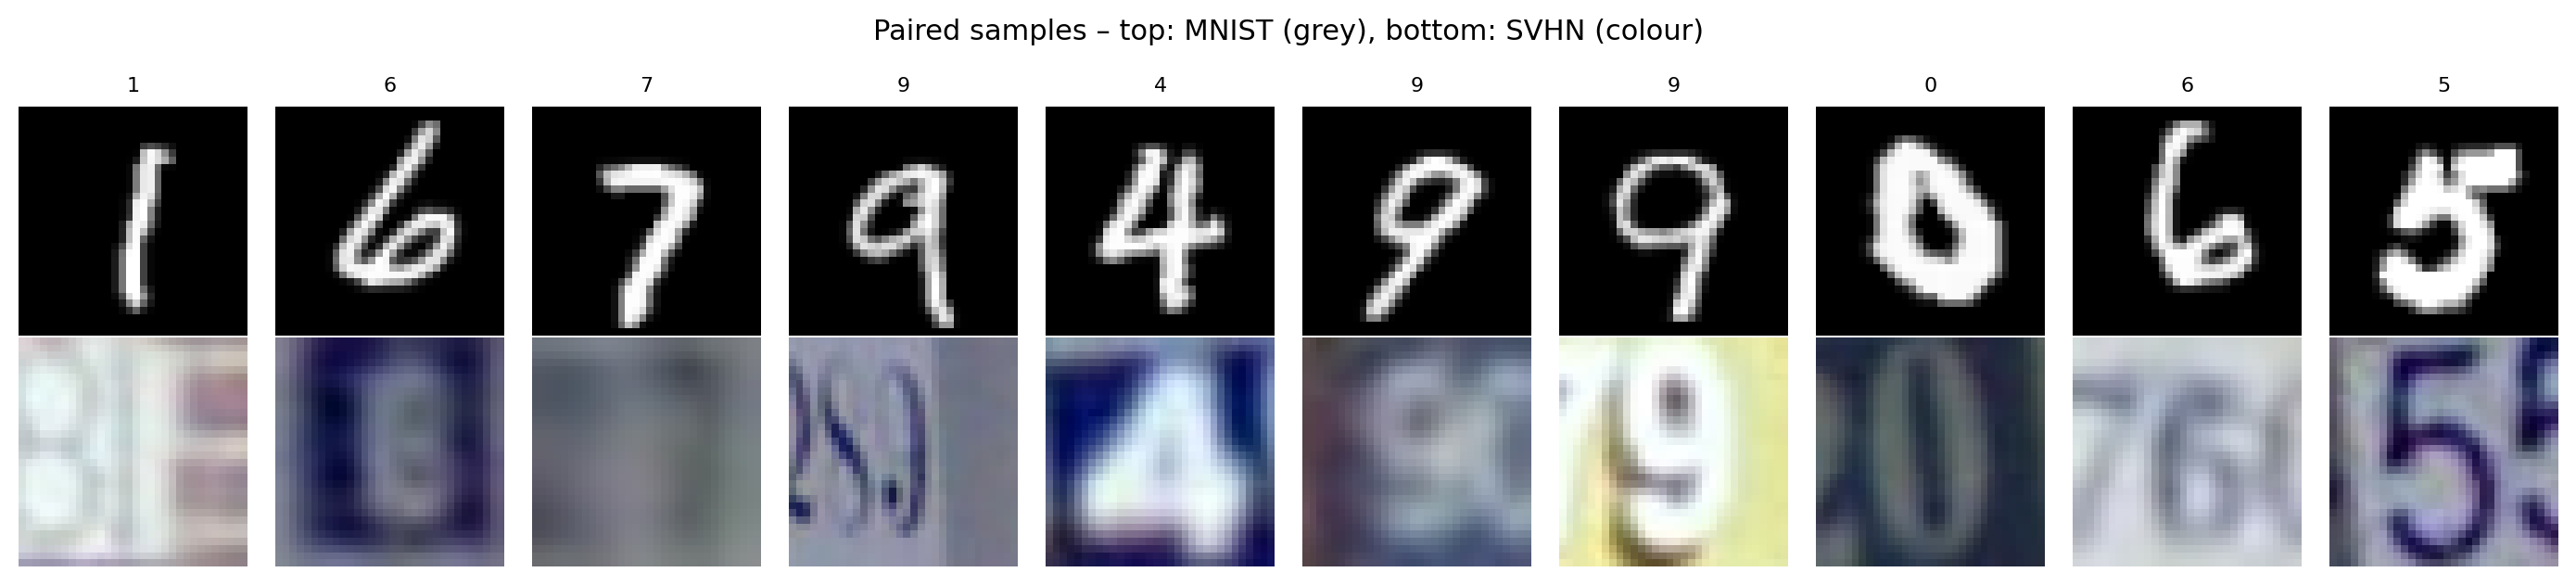

In [5]:
def unnorm(x):
    return (x * 0.5 + 0.5).clamp(0.0, 1.0)

def show_pairs(x_m, x_s, labels, n=10, title='Paired samples', save_path=None):
    n = min(n, len(x_m))
    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3.2))
    for i in range(n):
        axes[0, i].imshow(unnorm(x_m[i]).squeeze().numpy(), cmap='gray')
        axes[0, i].set_title(str(int(labels[i])), fontsize=8)
        axes[0, i].axis('off')
        axes[1, i].imshow(unnorm(x_s[i]).permute(1, 2, 0).numpy())
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('MNIST', fontsize=9)
    axes[1, 0].set_ylabel('SVHN',  fontsize=9)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

show_pairs(x_m_batch, x_s_batch, lbl_batch,
           title='Paired samples – top: MNIST (grey), bottom: SVHN (colour)',
           save_path=os.path.join(FIGURES_DIR, '01_paired_samples.png'))

*Each column shares the same digit label. The visual styles are very different: clean strokes vs. blurry street photos. The shared latent space must learn what is common.*

## 3. Multi-View VAE

### 3.1 Architecture overview

We have **one encoder and one decoder per view**:

| Component | Input | Output |
|-----------|-------|--------|
| `enc_m`   | MNIST $[B,1,32,32]$    | $(\mu_m,\,\log\sigma^2_m)$ each $[B, d_z]$ |
| `enc_s`   | SVHN  $[B,3,32,32]$    | $(\mu_s,\,\log\sigma^2_s)$ each $[B, d_z]$ |
| `dec_m`   | $\mathbf{z}\;[B,d_z]$  | MNIST mean $[B,1,32,32]$ |
| `dec_s`   | $\mathbf{z}\;[B,d_z]$  | SVHN mean  $[B,3,32,32]$ |

The architecture is adapted from the CelebA reference (64×64) to 32×32 by removing one strided conv layer.

**Encoder** for 32×32 input with $C_\text{in}$ channels:

$$[B,C_{in},32,32]
  \xrightarrow{32,\text{s}2} [B,32,16,16]
  \xrightarrow{64,\text{s}2} [B,64,8,8]
  \xrightarrow{128,\text{s}2} [B,128,4,4]
  \xrightarrow{256,k4,\text{s}1} [B,256,1,1]
  \xrightarrow{\text{linear}} [B,2d_z]$$

First $d_z$ elements → $\mu$; last $d_z$ pass through **Softplus** → variance $\sigma^2>0$.

**Decoder** (mirror with transposed convolutions, **Tanh** output → $[-1,1]$).

In [6]:
class Encoder(nn.Module):
    def __init__(self, channels_in, dimz):
        super().__init__()
        self.dimz = dimz
        self.net = nn.Sequential(
            nn.Conv2d(channels_in, 32,  4, 2, 1), nn.ReLU(),
            nn.Conv2d(32,          64,  4, 2, 1), nn.ReLU(),
            nn.Conv2d(64,          128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128,         256, 4, 1, 0), nn.ReLU(),
        )
        self.linear   = nn.Linear(256, dimz * 2)
        self.softplus = nn.Softplus()

    def forward(self, x):
        h   = self.net(x).view(-1, 256)
        out = self.linear(h)
        mu     = out[:, :self.dimz]
        # softplus ensures variance > 0; +1e-8 avoids log(0)
        logvar = torch.log(self.softplus(out[:, self.dimz:]) + 1e-8)
        return mu, logvar

In [7]:
class Decoder(nn.Module):
    def __init__(self, channels_out, dimz):
        super().__init__()
        self.linear = nn.Linear(dimz, 256)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128,          4, 1, 0), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,           4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64,  32,           4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32,  channels_out, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, z):
        h = torch.relu(self.linear(z)).view(-1, 256, 1, 1)
        return self.net(h)

### 3.2 Product of Experts joint posterior

Given encoder posteriors $q_i(\mathbf{z}|\mathbf{x}_i) = \mathcal{N}(\mu_i, \sigma_i^2 I)$,
the **Product of Experts** (PoE) joint posterior is:

$$q(\mathbf{z}|\mathbf{x}_1,\mathbf{x}_2) \propto p(\mathbf{z}) \cdot q_1(\mathbf{z}|\mathbf{x}_1) \cdot q_2(\mathbf{z}|\mathbf{x}_2)$$

Because every factor is Gaussian, so is the product. The combined parameters are:

$$\frac{1}{\sigma_*^2} = \underbrace{1}_{\text{prior}} + \sum_i \frac{1}{\sigma_i^2},
\qquad
\mu_* = \sigma_*^2 \sum_i \frac{\mu_i}{\sigma_i^2}$$

We always include the **prior expert** ($\mu=0$, $\sigma^2=1$) so the posterior
stays well-regularised even with only one view at inference time.

In [8]:
def product_of_experts(mu_list, logvar_list):
    '''PoE with isotropic Gaussian prior expert (mu=0, var=1).
    Args: lists of [B, dimz] tensors.
    Returns: (mu_joint, logvar_joint) each [B, dimz].'''
    T  = torch.ones_like(mu_list[0])   # prior precision = 1
    Tm = torch.zeros_like(mu_list[0])  # prior mu*precision = 0
    for mu, logvar in zip(mu_list, logvar_list):
        prec = torch.exp(-logvar)
        T  = T  + prec
        Tm = Tm + mu * prec
    var_j    = 1.0 / T
    mu_j     = Tm * var_j
    logvar_j = torch.log(var_j)
    return mu_j, logvar_j

### 3.3 Full model

`MultiViewVAE` wires all four modules together.
In `forward` each encoder is called **once**; its output is reused for both
the joint PoE path and its own unimodal path.
This avoids redundant computation while enabling all three sub-ELBOs in Section 4.

In [9]:
class MultiViewVAE(nn.Module):

    def __init__(self, dimz=64, var_x=0.1):
        super().__init__()
        self.dimz  = dimz
        self.var_x = var_x
        self.enc_m = Encoder(channels_in=1, dimz=dimz)
        self.enc_s = Encoder(channels_in=3, dimz=dimz)
        self.dec_m = Decoder(channels_out=1, dimz=dimz)
        self.dec_s = Decoder(channels_out=3, dimz=dimz)

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)

    def encode_joint(self, x_m, x_s):
        mu_m, lv_m = self.enc_m(x_m)
        mu_s, lv_s = self.enc_s(x_s)
        return product_of_experts([mu_m, mu_s], [lv_m, lv_s])

    def forward(self, x_m, x_s):
        mu_m, lv_m = self.enc_m(x_m)
        mu_s, lv_s = self.enc_s(x_s)
        mu_j, lv_j = product_of_experts([mu_m, mu_s], [lv_m, lv_s])

        z_j = self.reparameterize(mu_j, lv_j)
        z_m = self.reparameterize(mu_m, lv_m)
        z_s = self.reparameterize(mu_s, lv_s)

        return dict(
            mu_j=mu_j, lv_j=lv_j,
            xm_j=self.dec_m(z_j), xs_j=self.dec_s(z_j),
            mu_m=mu_m, lv_m=lv_m, xm_m=self.dec_m(z_m),
            mu_s=mu_s, lv_s=lv_s, xs_s=self.dec_s(z_s),
        )

    @torch.no_grad()
    def sample_prior(self, n):
        z = torch.randn(n, self.dimz, device=next(self.parameters()).device)
        return self.dec_m(z).cpu(), self.dec_s(z).cpu()

    @torch.no_grad()
    def cross_generate(self, x, source='mnist'):
        '''Encode one view using its mean (no noise), decode the other.'''
        if source == 'mnist':
            mu, _ = self.enc_m(x)
            return self.dec_s(mu).cpu()
        else:
            mu, _ = self.enc_s(x)
            return self.dec_m(mu).cpu()

### 3.4 Loss functions

**Gaussian log-likelihood** (batch-averaged, same formulation as the CelebA reference):

$$\ell_\text{rec}(\mathbf{x},\hat{\mathbf{x}}) =
  -\frac{1}{N}\sum_{i=1}^N \!\left[\tfrac{D}{2}\ln(2\pi\sigma_x^2)
  + \frac{\|\mathbf{x}^{(i)}-\hat{\mathbf{x}}^{(i)}\|^2}{2\sigma_x^2}\right]$$

**KL divergence** (closed form, Kingma & Welling 2014):

$$D_{\mathrm{KL}} = -\frac{1}{2N}\sum_{i,j}\!\left(1 + \log\sigma_{ij}^2 - \mu_{ij}^2 - \sigma_{ij}^2\right)$$

**Total objective** (three sub-ELBOs):

$$\mathcal{L} = -\!\left[\,\underbrace{\ell_m^j + \ell_s^j - \beta\,\mathrm{KL}_j}_{\text{joint ELBO}}
  + \alpha\!\left(\underbrace{\ell_m - \beta\,\mathrm{KL}_m}_{\text{MNIST ELBO}}
  + \underbrace{\ell_s - \beta\,\mathrm{KL}_s}_{\text{SVHN ELBO}}\right)\right]$$

The unimodal ELBOs ensure each encoder can reconstruct its view alone—required for cross-generation.
A $\beta$-warmup (linear 0→1 over the first 10 epochs) avoids early posterior collapse.

In [10]:
def gaussian_loglik(x, mu_x, var_x):
    D    = x.shape[1] * x.shape[2] * x.shape[3]
    diff = x.reshape(-1, D) - mu_x.reshape(-1, D)
    return (-0.5 * (D * np.log(2 * np.pi * var_x) + diff.pow(2).sum(1) / var_x)).mean()

def kl_gaussian(mu, logvar):
    return (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(1)).mean()

def compute_loss(out, x_m, x_s, var_x=0.1, alpha=1.0, beta=1.0):
    ej = gaussian_loglik(x_m, out['xm_j'], var_x) + \
         gaussian_loglik(x_s, out['xs_j'], var_x) - \
         beta * kl_gaussian(out['mu_j'], out['lv_j'])
    em = gaussian_loglik(x_m, out['xm_m'], var_x) - \
         beta * kl_gaussian(out['mu_m'], out['lv_m'])
    es = gaussian_loglik(x_s, out['xs_s'], var_x) - \
         beta * kl_gaussian(out['mu_s'], out['lv_s'])
    # negate because we minimise loss but the ELBO is to be maximised
    loss = -(ej + alpha * (em + es))
    return loss, ej.item(), em.item(), es.item()

## 4. Training

We train for **30 epochs** with Adam ($\text{lr}=10^{-3}$, batch size 128).
Checkpoints are saved every 5 epochs and the notebook is fully resumable.
Set `FORCE_RETRAIN = True` to start from scratch.

| Hyper-parameter | Value | Reason |
|---|---|---|
| `dimz` | 64 | Enough capacity; not too large for 30-epoch training |
| `var_x` | 0.1 | Same as CelebA reference (fixed reconstruction noise) |
| `alpha` | 1.0 | Equal weight to joint and unimodal ELBOs |
| $\beta$ warmup | 0 → 1 over 10 epochs | Prevents early KL collapse |

On a Colab T4 GPU: ~10 min.  On CPU: ~60–90 min.

In [11]:
DIMZ          = 64
VAR_X         = 0.1
LR            = 1e-3
EPOCHS        = 30
ALPHA         = 1.0
BETA_MAX      = 1.0
WARMUP        = 10
SAVE_EVERY    = 5
FORCE_RETRAIN = False

def beta_schedule(epoch):
    # guard against division by zero when warmup is disabled
    if WARMUP == 0:
        return BETA_MAX
    return min(BETA_MAX, BETA_MAX * epoch / WARMUP)

model     = MultiViewVAE(dimz=DIMZ, var_x=VAR_X).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

start_epoch = 0
history = {'loss': [], 'elbo_j': [], 'elbo_m': [], 'elbo_s': []}

if not FORCE_RETRAIN and os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt['epoch'] + 1
    history     = ckpt['history']
    print(f"Checkpoint loaded – resuming from epoch {start_epoch}/{EPOCHS}")
else:
    print("Training from scratch.")

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Training from scratch.
Parameters: 2,857,092


In [12]:
def run_epoch(model, loader, optimizer, var_x, alpha, beta):
    model.train()
    totals = {'loss': 0., 'ej': 0., 'em': 0., 'es': 0.}
    for x_m, x_s, _ in loader:
        x_m, x_s = x_m.to(device), x_s.to(device)
        optimizer.zero_grad()
        out = model(x_m, x_s)
        loss, ej, em, es = compute_loss(out, x_m, x_s, var_x, alpha, beta)
        loss.backward()
        optimizer.step()
        totals['loss'] += loss.item()
        totals['ej']   += ej
        totals['em']   += em
        totals['es']   += es
    n = len(loader)
    return {k: v / n for k, v in totals.items()}

if start_epoch >= EPOCHS:
    print(f"Training already complete ({EPOCHS} epochs). Skipping.")
else:
    for epoch in range(start_epoch, EPOCHS):
        beta = beta_schedule(epoch)
        t0   = time.time()
        m    = run_epoch(model, train_loader, optimizer, VAR_X, ALPHA, beta)
        dt   = time.time() - t0

        history['loss'].append(m['loss'])
        history['elbo_j'].append(m['ej'])
        history['elbo_m'].append(m['em'])
        history['elbo_s'].append(m['es'])

        if (epoch + 1) % SAVE_EVERY == 0 or epoch == EPOCHS - 1:
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(), 'history': history},
                       CHECKPOINT_PATH)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{EPOCHS}  beta={beta:.2f}  "
                  f"loss={m['loss']:9.2f}  "
                  f"ELBO_j={m['ej']:8.2f}  "
                  f"ELBO_m={m['em']:8.2f}  "
                  f"ELBO_s={m['es']:8.2f}  ({dt:.1f}s)")
    print("Training complete.")

Epoch   5/30  beta=0.40  loss=   340.28  ELBO_j= -167.60  ELBO_m= -344.57  ELBO_s=  171.89  (10.3s)
Epoch  10/30  beta=0.90  loss=  -567.32  ELBO_j=  288.68  ELBO_m=  -26.38  ELBO_s=  305.03  (10.2s)
Epoch  15/30  beta=1.00  loss=  -804.26  ELBO_j=  405.97  ELBO_m=   31.09  ELBO_s=  367.20  (10.1s)
Epoch  20/30  beta=1.00  loss=  -930.52  ELBO_j=  468.01  ELBO_m=   59.15  ELBO_s=  403.36  (10.4s)
Epoch  25/30  beta=1.00  loss= -1000.84  ELBO_j=  502.35  ELBO_m=   74.98  ELBO_s=  423.51  (10.3s)
Epoch  30/30  beta=1.00  loss= -1058.89  ELBO_j=  531.02  ELBO_m=   85.39  ELBO_s=  442.48  (10.3s)
Training complete.


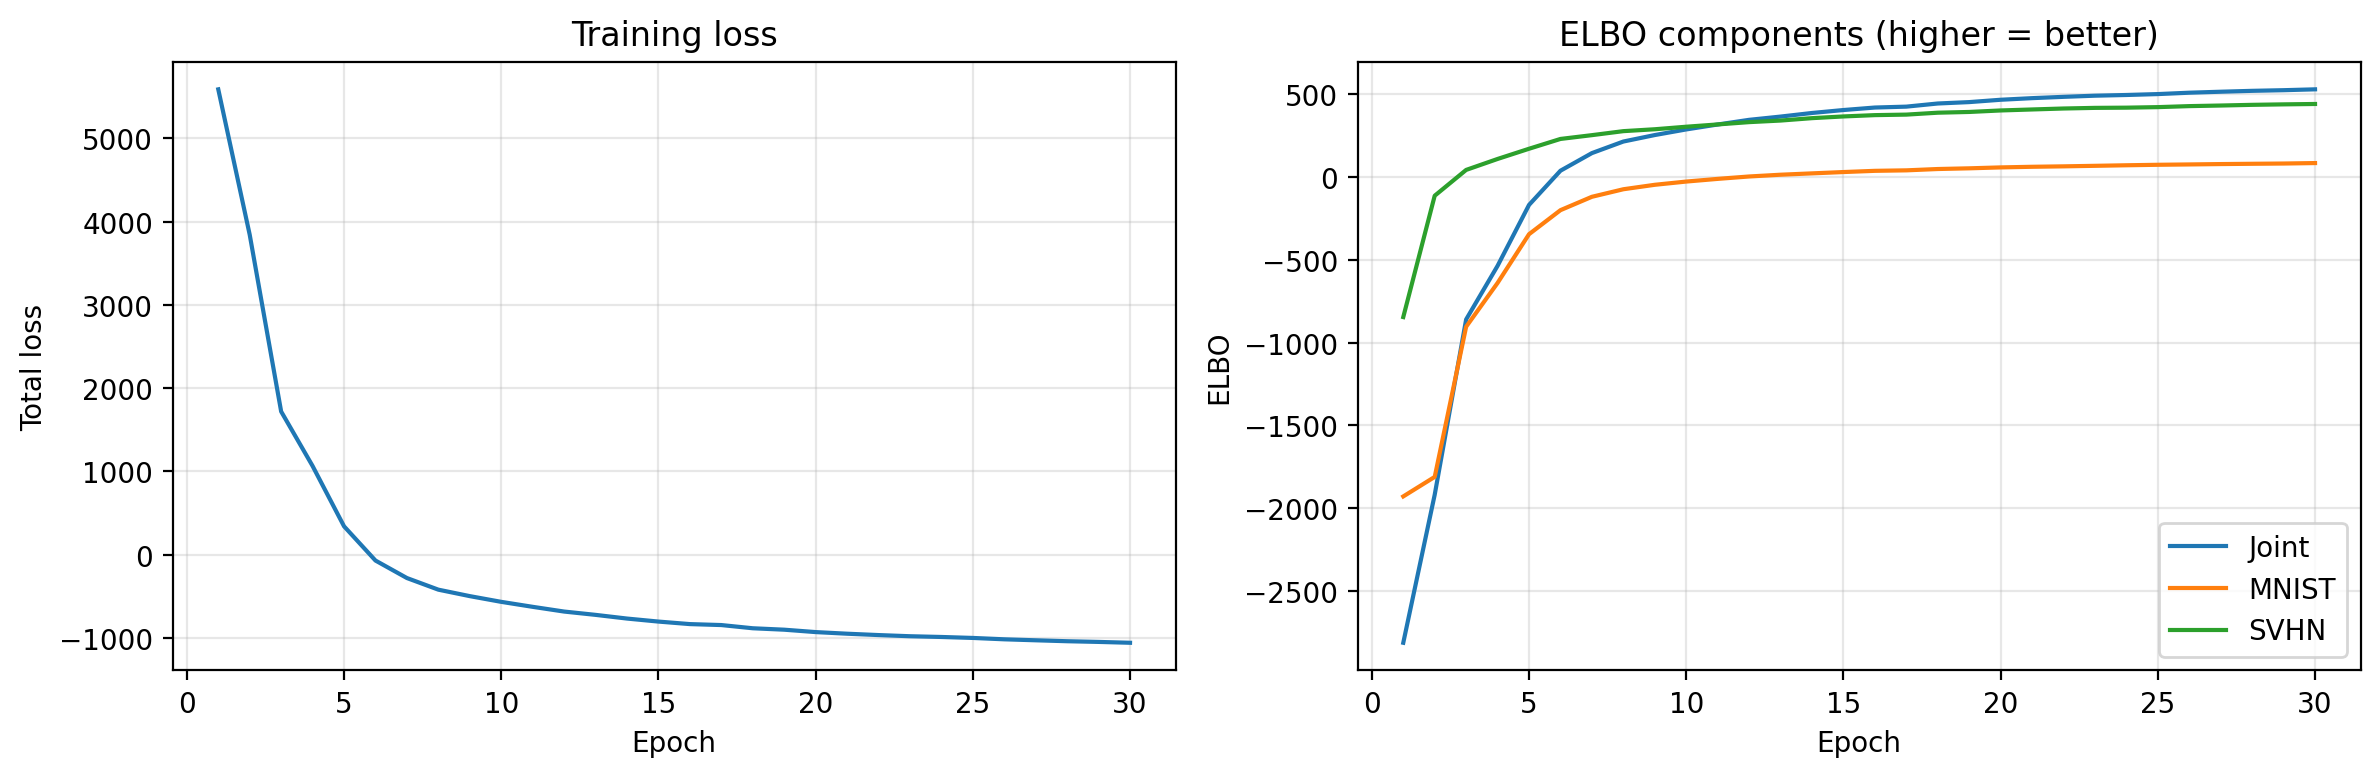

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = list(range(1, len(history['loss']) + 1))

axes[0].plot(ep, history['loss'])
axes[0].set(xlabel='Epoch', ylabel='Total loss', title='Training loss')
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['elbo_j'], label='Joint')
axes[1].plot(ep, history['elbo_m'], label='MNIST')
axes[1].plot(ep, history['elbo_s'], label='SVHN')
axes[1].set(xlabel='Epoch', ylabel='ELBO', title='ELBO components (higher = better)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '02_loss_curves.png'), dpi=100, bbox_inches='tight')
plt.show()

*The total loss should decrease monotonically. The joint ELBO is initially lower than the unimodal ones because it must reconstruct both views; all three should converge.*

## 5. Reconstruction

We encode 8 test pairs with the **joint posterior** (both views) and decode each view.
Good reconstruction means the model has captured the relevant information in the latent space.

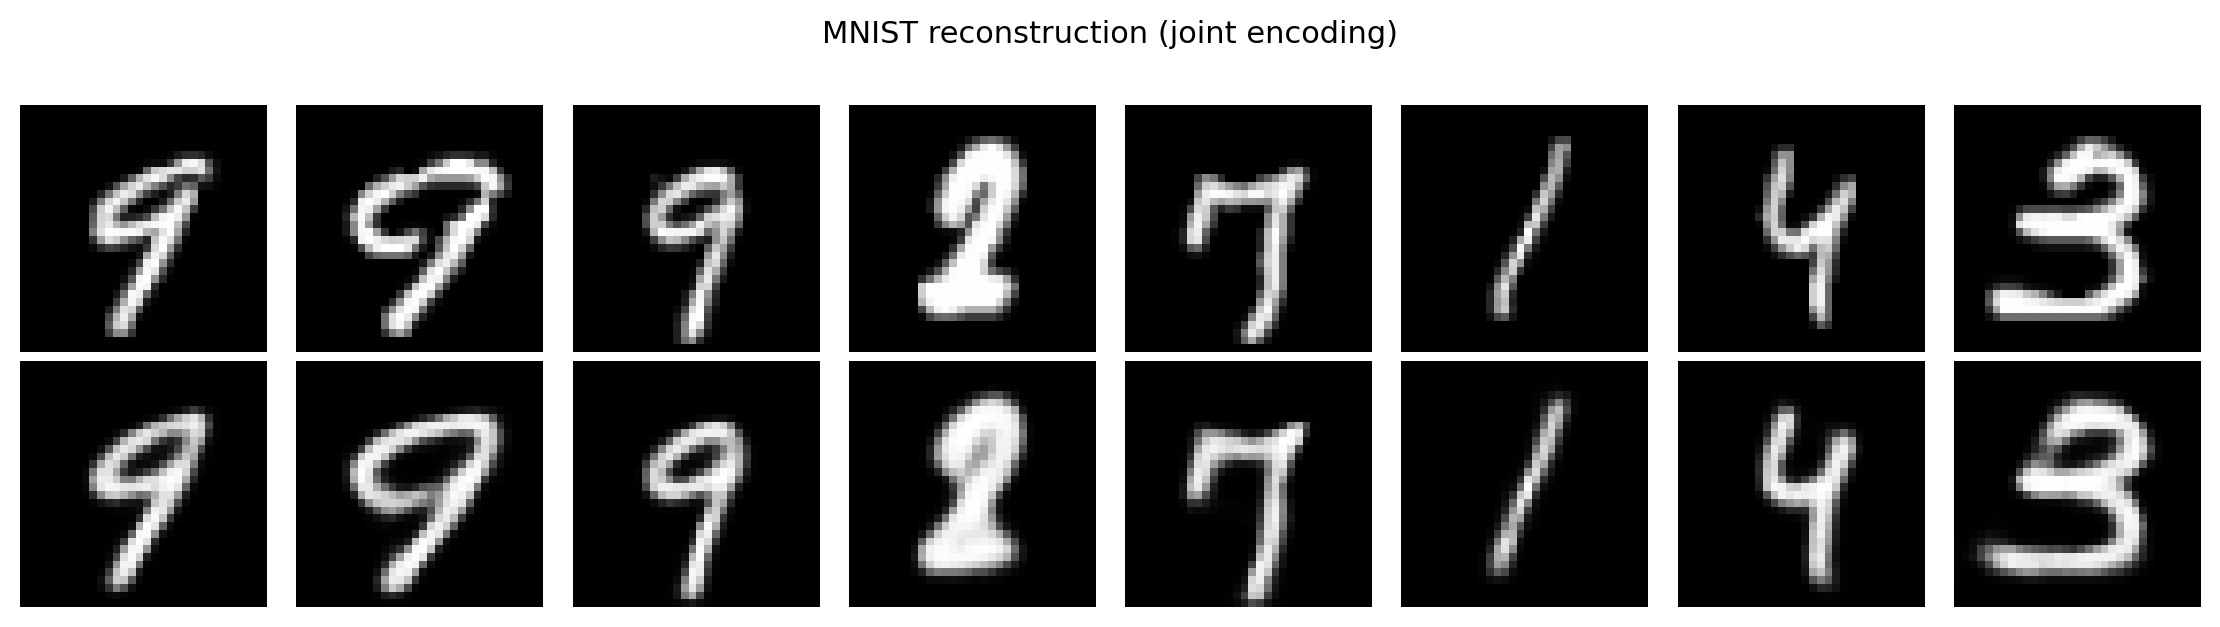

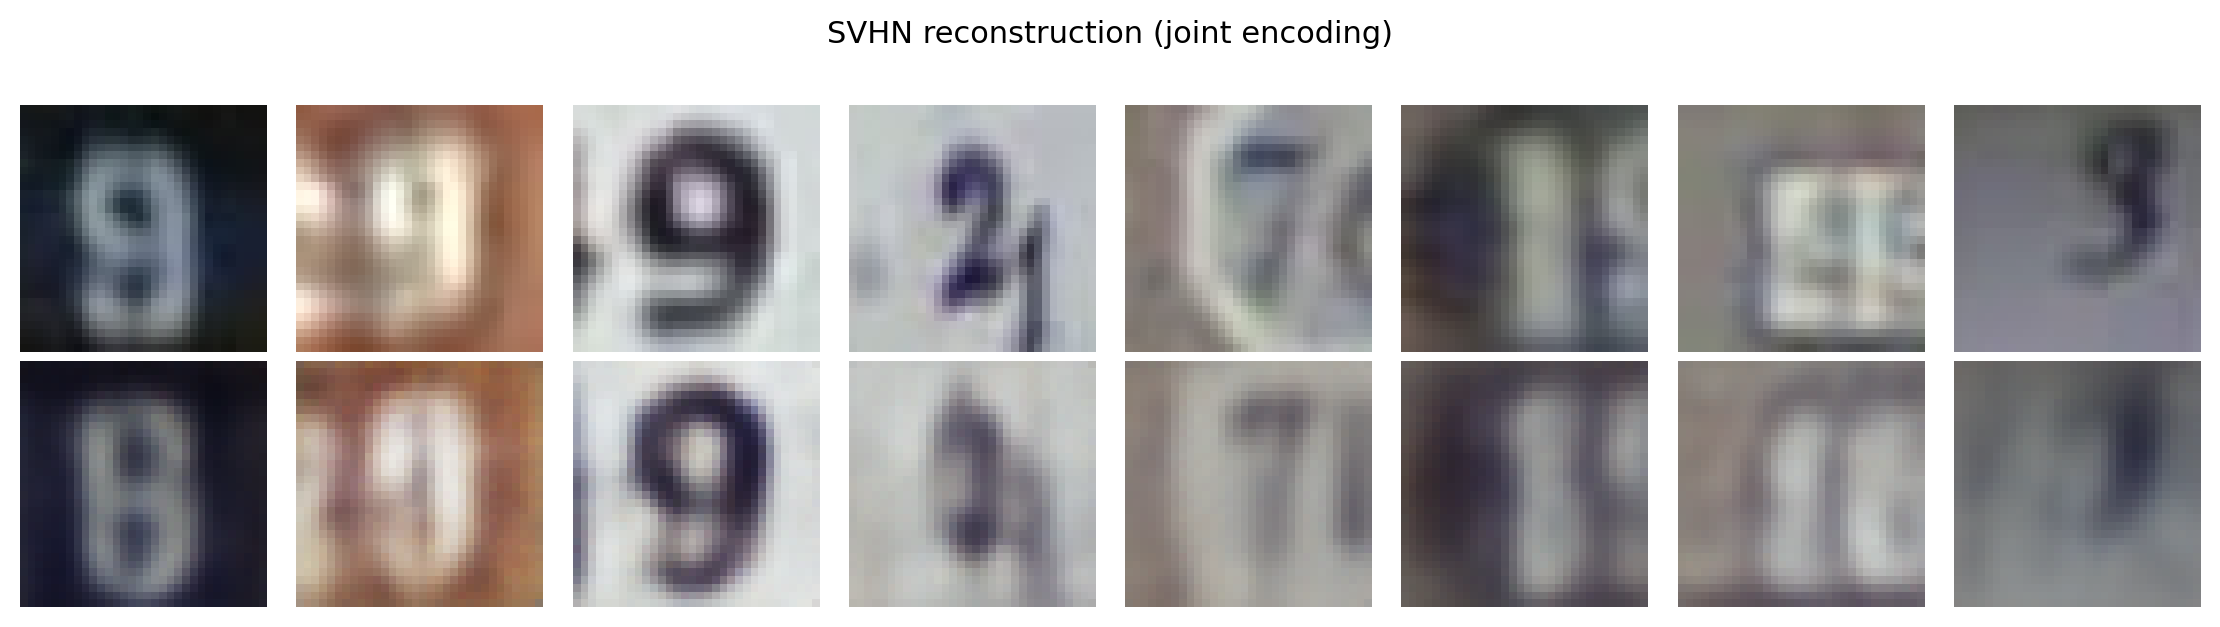

In [14]:
model.eval()

x_m_t, x_s_t, lbl_t = next(iter(test_loader))
x_m_t8 = x_m_t[:8].to(device)
x_s_t8 = x_s_t[:8].to(device)

with torch.no_grad():
    out = model(x_m_t8, x_s_t8)

xm_recon = out['xm_j'].cpu()
xs_recon = out['xs_j'].cpu()

def show_recon(originals, recons, title, cmap=None, save_path=None):
    n = len(originals)
    fig, axes = plt.subplots(2, n, figsize=(n * 1.4, 3.2))
    for i in range(n):
        o, r = unnorm(originals[i]), unnorm(recons[i])
        if cmap:
            axes[0, i].imshow(o.squeeze().numpy(), cmap=cmap)
            axes[1, i].imshow(r.squeeze().numpy(), cmap=cmap)
        else:
            axes[0, i].imshow(o.permute(1, 2, 0).numpy())
            axes[1, i].imshow(r.permute(1, 2, 0).numpy())
        for row in axes[:, i]: row.axis('off')
    axes[0, 0].set_ylabel('Original', fontsize=9)
    axes[1, 0].set_ylabel('Recon.',   fontsize=9)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()

show_recon(x_m_t8.cpu(), xm_recon,
           'MNIST reconstruction (joint encoding)',
           cmap='gray',
           save_path=os.path.join(FIGURES_DIR, '03a_mnist_recon.png'))

show_recon(x_s_t8.cpu(), xs_recon,
           'SVHN reconstruction (joint encoding)',
           save_path=os.path.join(FIGURES_DIR, '03b_svhn_recon.png'))

*MNIST reconstructions should be sharp; SVHN reconstructions are blurrier because SVHN has more visual variety (backgrounds, fonts, lighting).*

## 6. Generation from the Prior

We sample $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and decode with both decoders.
Both outputs come from the same $\mathbf{z}$, so they should represent the same digit.

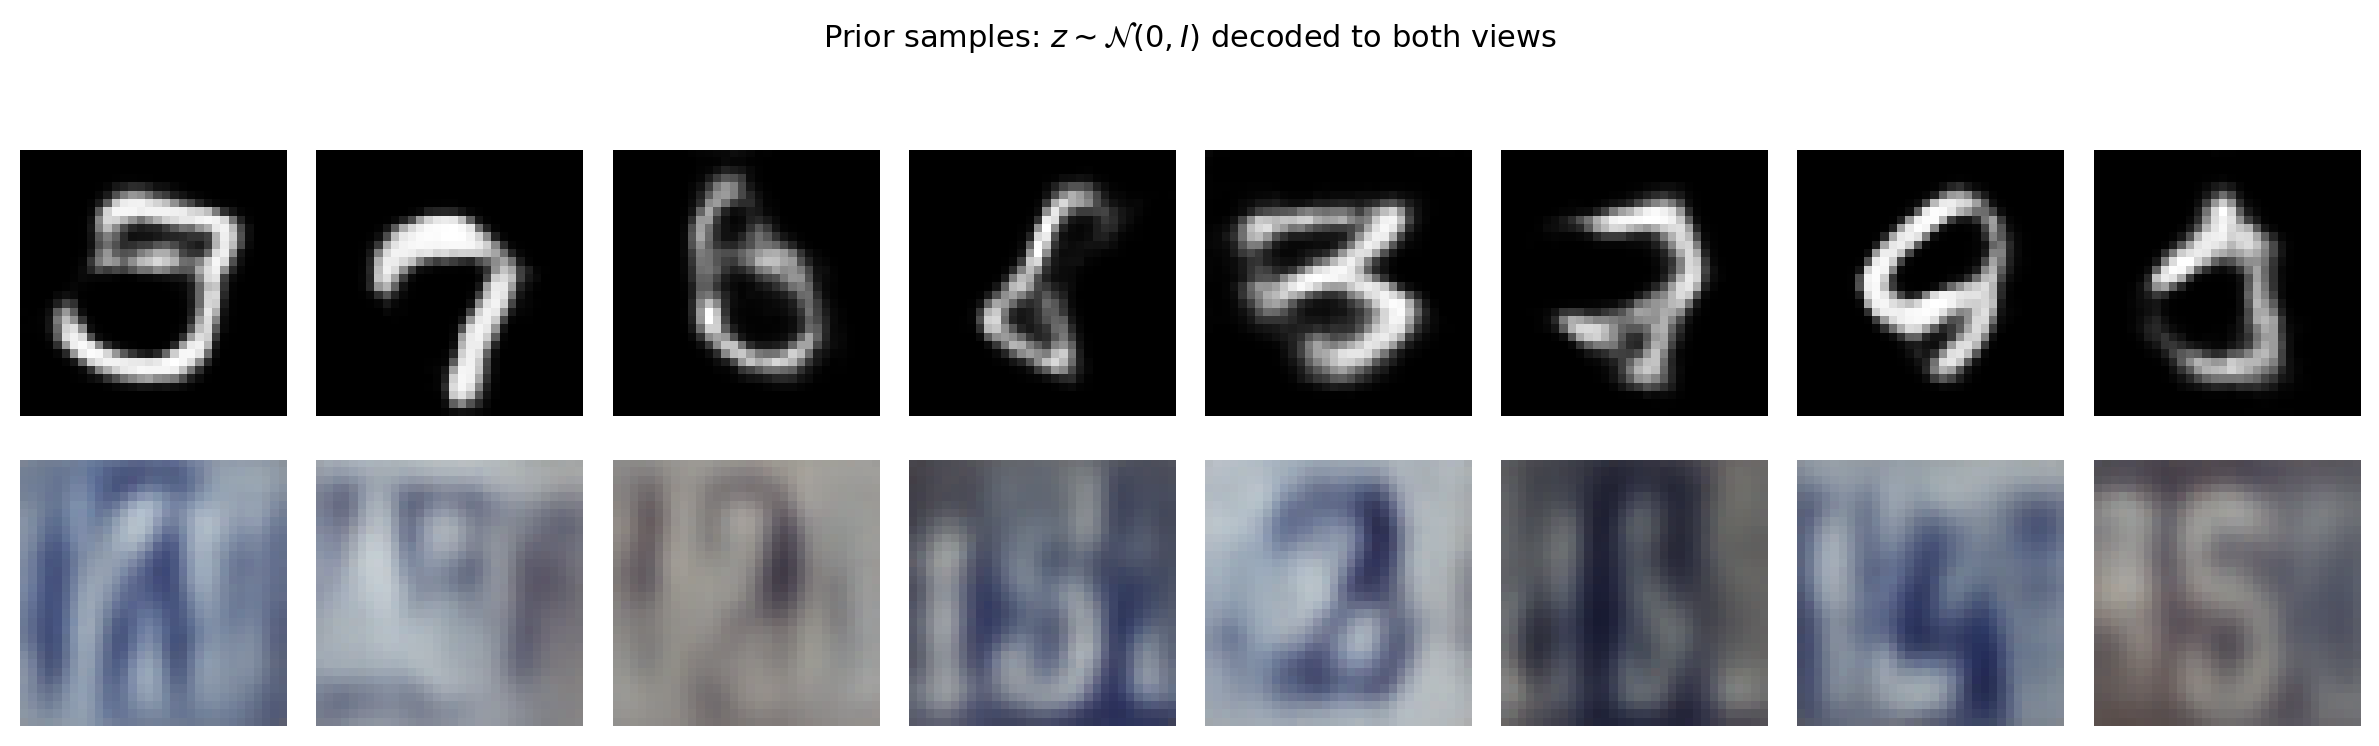

In [15]:
model.eval()
with torch.no_grad():
    xm_samp, xs_samp = model.sample_prior(16)

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i in range(8):
    axes[0, i].imshow(unnorm(xm_samp[i]).squeeze().numpy(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(unnorm(xs_samp[i]).permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('MNIST', fontsize=10)
axes[1, 0].set_ylabel('SVHN',  fontsize=10)
fig.suptitle(r'Prior samples: $z \sim \mathcal{N}(0,I)$ decoded to both views', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_prior_samples.png'), dpi=100, bbox_inches='tight')
plt.show()

*Each column is one sample. If the shared latent space is well-learned, both rows in each column show the same digit class.*

## 7. Cross-Domain Generation

This is the main test for a multi-view VAE.
We encode **one view only** and decode with the **other decoder**.
We use the encoder mean (no reparameterisation noise) for cleaner outputs.

- **MNIST → SVHN**: encode with `enc_m`, decode with `dec_s`.
- **SVHN → MNIST**: encode with `enc_s`, decode with `dec_m`.

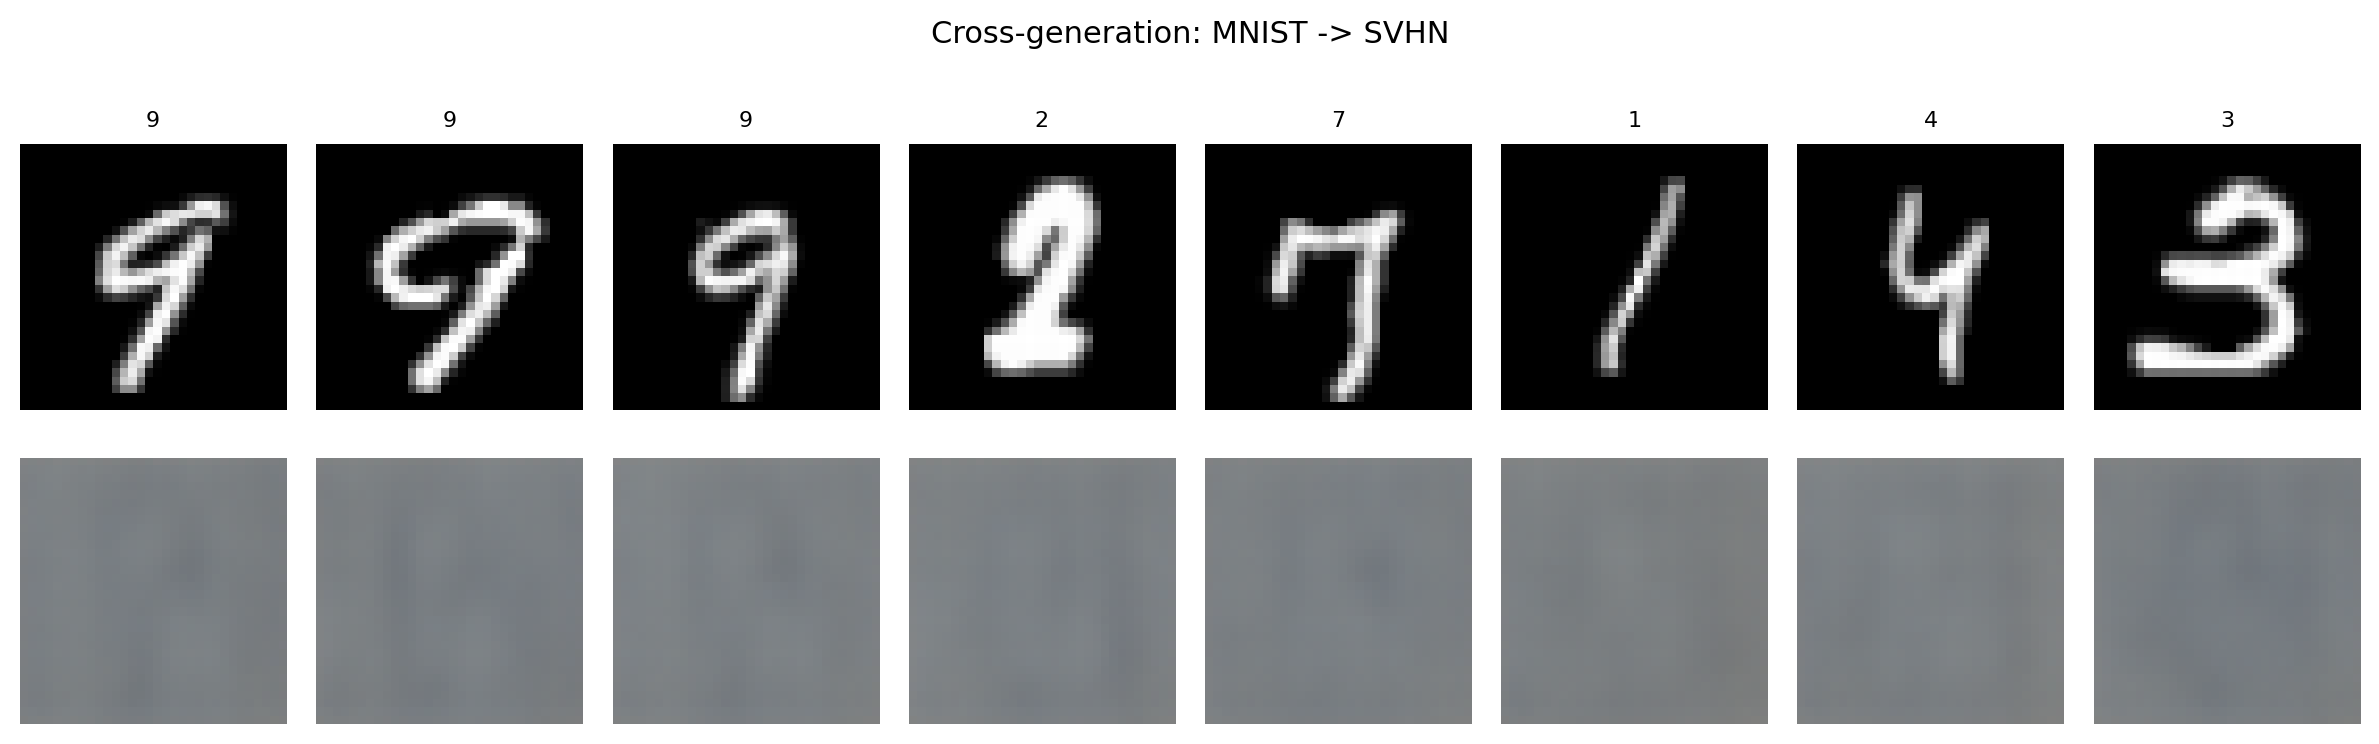

In [16]:
model.eval()

xs_from_m = model.cross_generate(x_m_t8, source='mnist')

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i in range(8):
    axes[0, i].imshow(unnorm(x_m_t8[i].cpu()).squeeze().numpy(), cmap='gray')
    axes[0, i].set_title(str(int(lbl_t[i])), fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(unnorm(xs_from_m[i]).permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('MNIST input',   fontsize=9)
axes[1, 0].set_ylabel('-> SVHN output', fontsize=9)
fig.suptitle('Cross-generation: MNIST -> SVHN', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05a_cross_m2s.png'), dpi=100, bbox_inches='tight')
plt.show()

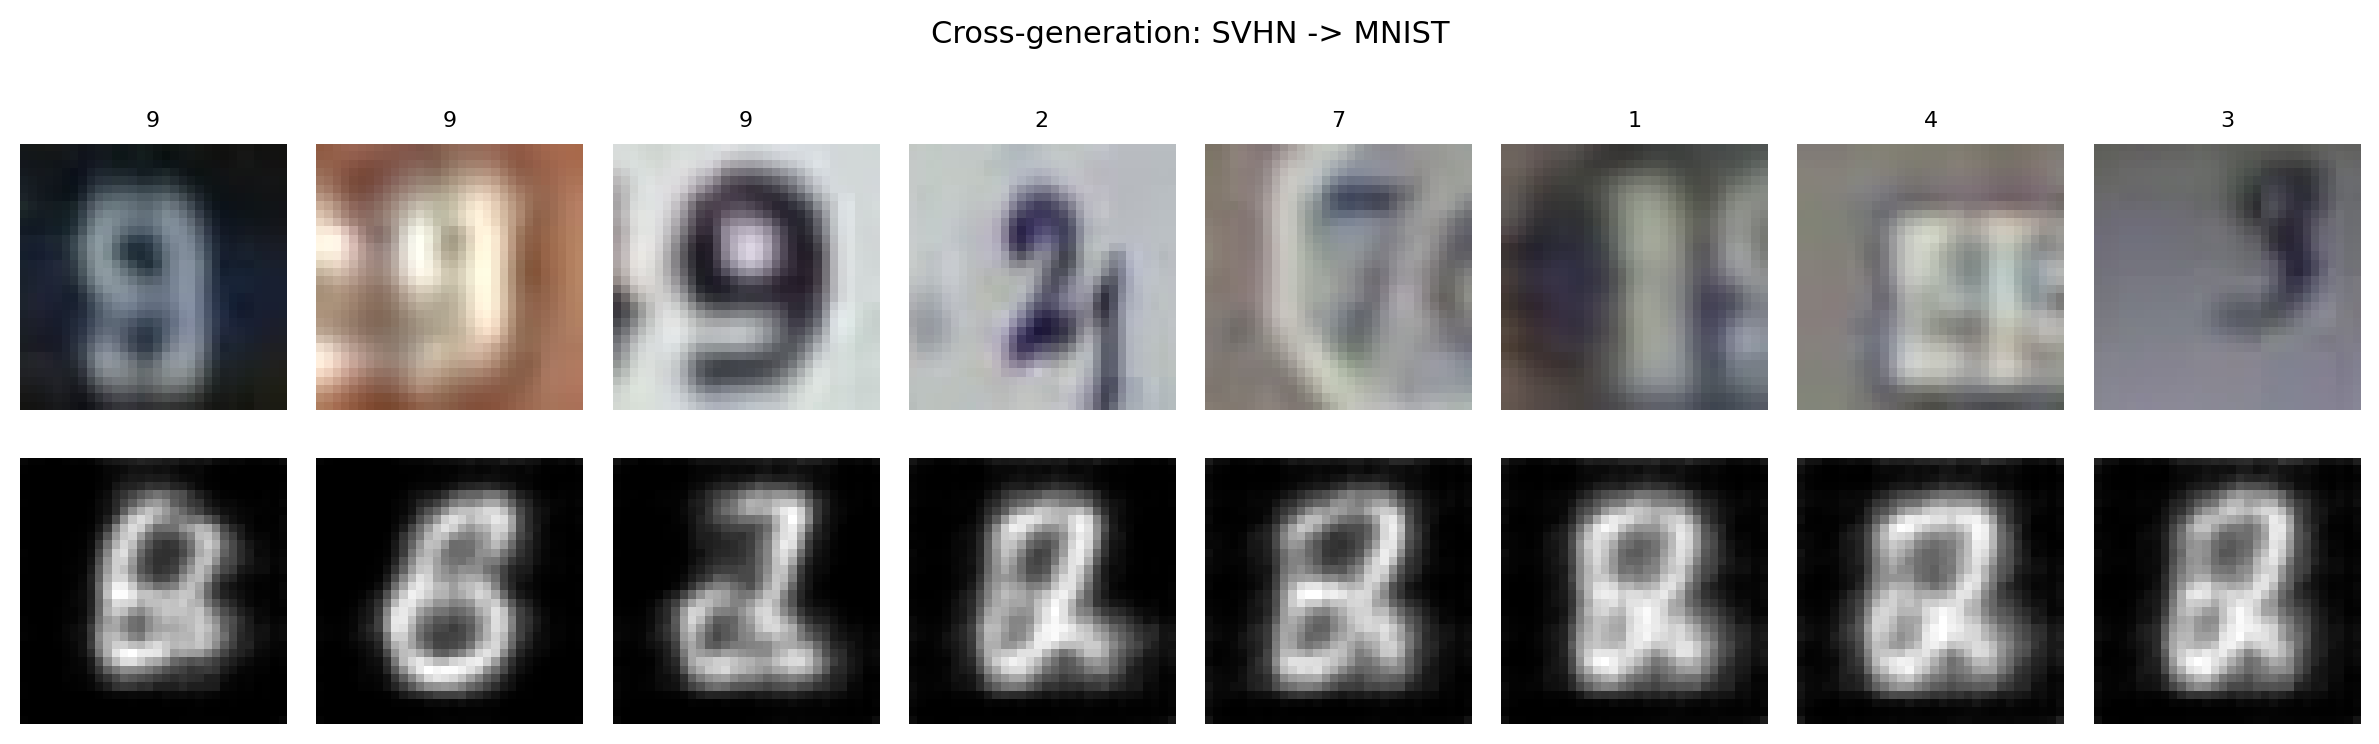

Check: do the digit labels in the title match the generated images?


In [17]:
xm_from_s = model.cross_generate(x_s_t8, source='svhn')

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i in range(8):
    axes[0, i].imshow(unnorm(x_s_t8[i].cpu()).permute(1, 2, 0).numpy())
    axes[0, i].set_title(str(int(lbl_t[i])), fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(unnorm(xm_from_s[i]).squeeze().numpy(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('SVHN input',     fontsize=9)
axes[1, 0].set_ylabel('-> MNIST output', fontsize=9)
fig.suptitle('Cross-generation: SVHN -> MNIST', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '05b_cross_s2m.png'), dpi=100, bbox_inches='tight')
plt.show()
print("Check: do the digit labels in the title match the generated images?")

### 7.1 Quantitative check – linear probe on the joint latent space

We train a logistic regression on the **joint** latent means and evaluate digit classification accuracy.
High accuracy (>80%) confirms the latent space encodes digit identity, a necessary condition for correct cross-generation.

In [18]:
def collect_latents(loader, model, max_batches=60):
    model.eval()
    mu_list, lbl_list = [], []
    with torch.no_grad():
        for i, (x_m, x_s, lbl) in enumerate(loader):
            if i >= max_batches:
                break
            mu_j, _ = model.encode_joint(x_m.to(device), x_s.to(device))
            mu_list.append(mu_j.cpu().numpy())
            lbl_list.append(lbl.numpy())
    return np.concatenate(mu_list), np.concatenate(lbl_list)

print("Collecting latents...")
Z_tr, y_tr = collect_latents(train_loader, model, max_batches=60)
Z_te, y_te = collect_latents(test_loader,  model, max_batches=40)

scaler  = StandardScaler()
Z_tr_sc = scaler.fit_transform(Z_tr)
Z_te_sc = scaler.transform(Z_te)

clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
clf.fit(Z_tr_sc, y_tr)
acc = clf.score(Z_te_sc, y_te)
print(f"\nLinear probe accuracy: {acc * 100:.1f}%")
print("(>80% is good; means the latent space clusters by digit class)")


Linear probe accuracy: 93.6%
(>80% is good; means the latent space clusters by digit class)


## 8. Latent Space Visualisation (t-SNE)

We reduce the 64-dimensional latent representations to 2D with t-SNE and colour them two ways:

1. **By digit label** (joint encoding) – well-separated clusters indicate good class structure.
2. **By view** (unimodal encodings) – overlap between MNIST and SVHN clusters means the
   two encoders have aligned their representations in the shared space.

Computing t-SNE (label-coloured)...


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_3414/2870534951.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap10 = plt.cm.get_cmap('tab10')


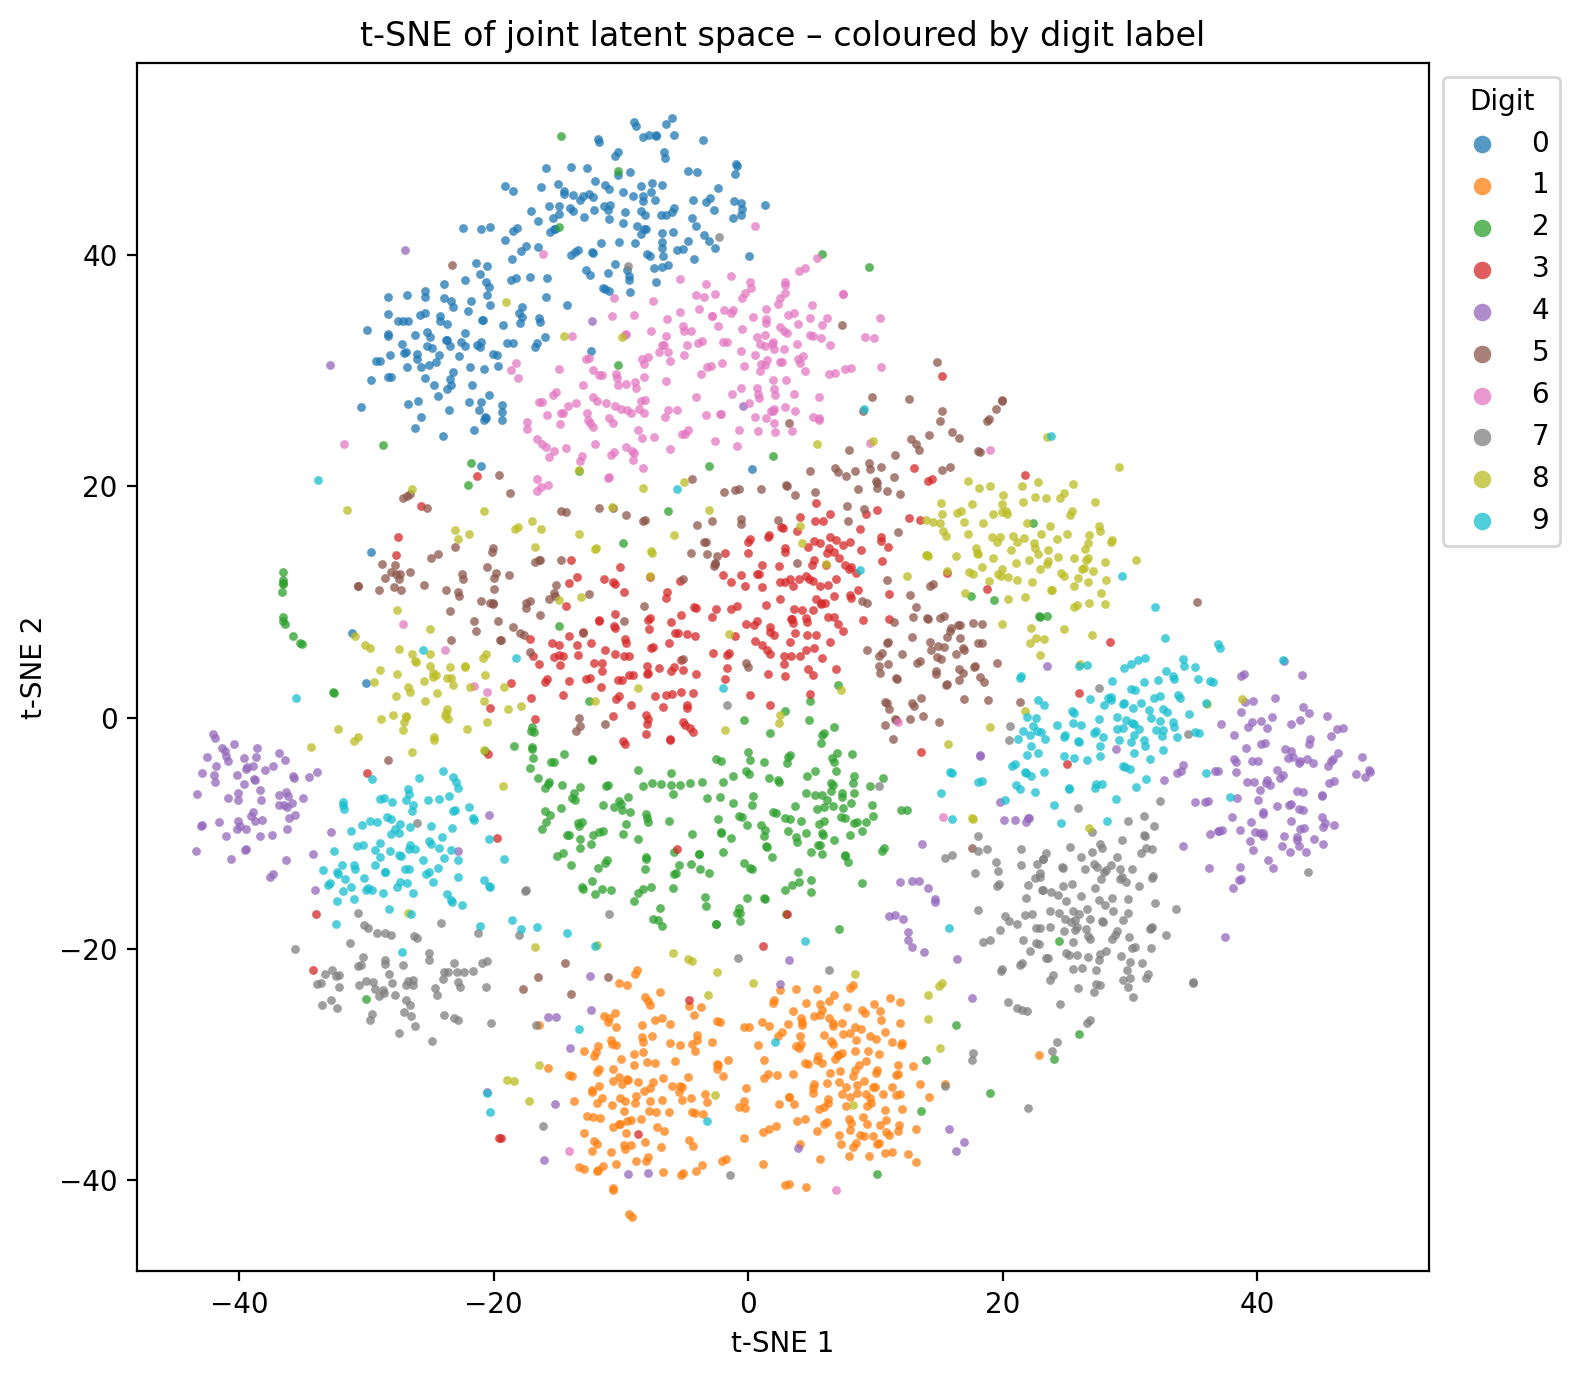

In [19]:
print("Computing t-SNE (label-coloured)...")
mu_j_all, lbl_all = collect_latents(test_loader, model, max_batches=20)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
Z2d  = tsne.fit_transform(mu_j_all)

cmap10 = plt.cm.get_cmap('tab10')
fig, ax = plt.subplots(figsize=(8, 7))
for c in range(10):
    mask = lbl_all == c
    ax.scatter(Z2d[mask, 0], Z2d[mask, 1], c=[cmap10(c)],
               label=str(c), s=10, alpha=0.75, linewidths=0)
ax.legend(title='Digit', markerscale=2, bbox_to_anchor=(1, 1), loc='upper left')
ax.set_title('t-SNE of joint latent space – coloured by digit label')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06a_tsne_label.png'), dpi=100, bbox_inches='tight')
plt.show()

Computing t-SNE (view-coloured)...


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


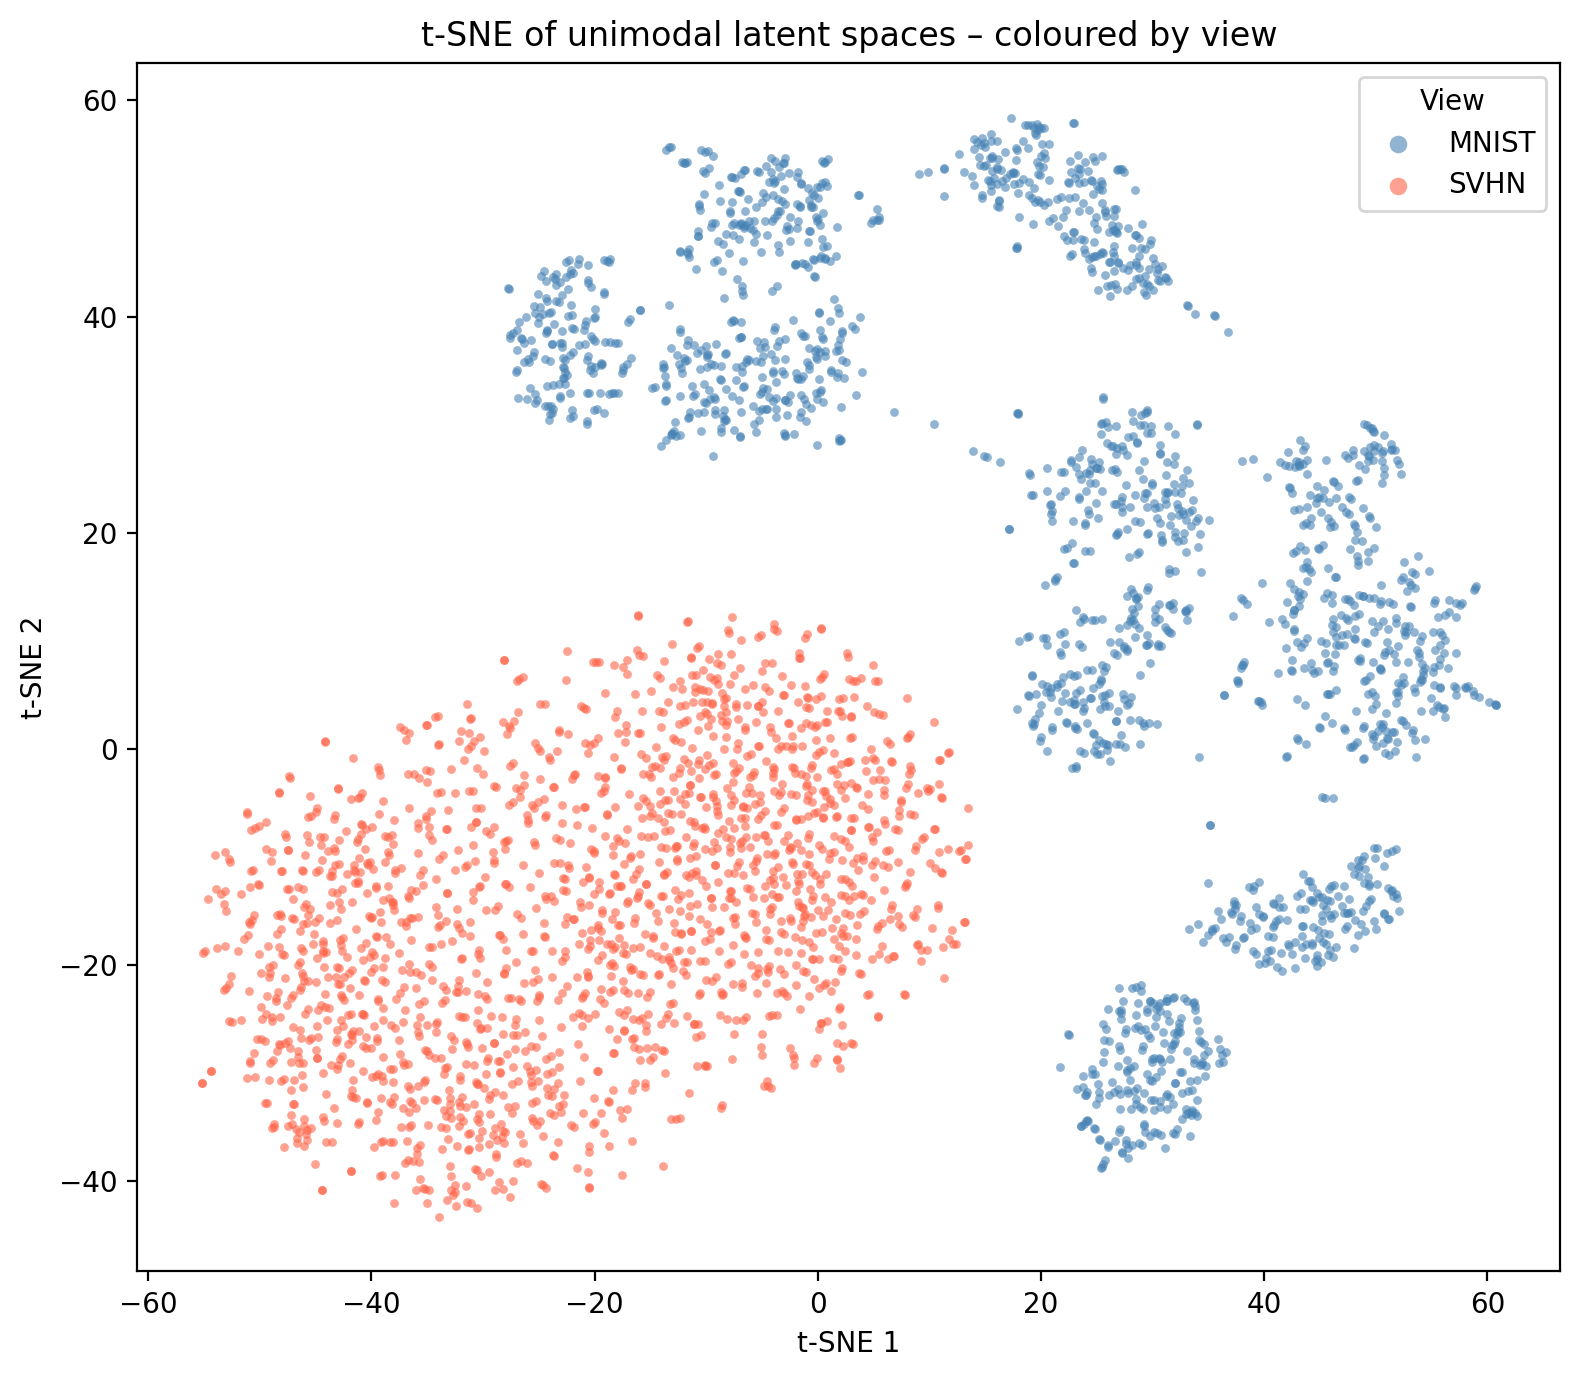

Overlap between MNIST and SVHN points = well-aligned shared space.


In [20]:
print("Computing t-SNE (view-coloured)...")

def collect_unimodal(loader, model, max_batches=15):
    model.eval()
    mu_m_list, mu_s_list, lbl_list = [], [], []
    with torch.no_grad():
        for i, (x_m, x_s, lbl) in enumerate(loader):
            if i >= max_batches:
                break
            mm, _ = model.enc_m(x_m.to(device))
            ms, _ = model.enc_s(x_s.to(device))
            mu_m_list.append(mm.cpu().numpy())
            mu_s_list.append(ms.cpu().numpy())
            lbl_list.append(lbl.numpy())
    return (np.concatenate(mu_m_list), np.concatenate(mu_s_list),
            np.concatenate(lbl_list))

mu_m_v, mu_s_v, _ = collect_unimodal(test_loader, model, max_batches=15)
mu_both  = np.concatenate([mu_m_v, mu_s_v])
view_lbl = np.array(['MNIST'] * len(mu_m_v) + ['SVHN'] * len(mu_s_v))

Z2d_v = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000).fit_transform(mu_both)

fig, ax = plt.subplots(figsize=(8, 7))
for name, color in [('MNIST', 'steelblue'), ('SVHN', 'tomato')]:
    mask = view_lbl == name
    ax.scatter(Z2d_v[mask, 0], Z2d_v[mask, 1], c=color, label=name,
               s=10, alpha=0.6, linewidths=0)
ax.legend(title='View', markerscale=2)
ax.set_title('t-SNE of unimodal latent spaces – coloured by view')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '06b_tsne_view.png'), dpi=100, bbox_inches='tight')
plt.show()
print("Overlap between MNIST and SVHN points = well-aligned shared space.")

## 9. Conclusions and Limitations

### What we did

1. **Dataset** – built a paired MNIST/SVHN dataset with deterministic, label-matched pairing.
2. **Model** – a multi-view VAE with one encoder and one decoder per view, sharing a 64-d latent space.
3. **Joint posterior** – Product of Experts with a prior expert, so each view's posterior remains well-calibrated.
4. **Training** – three sub-ELBOs (joint + 2 unimodal) with KL warm-up to avoid early posterior collapse.
5. **Results** – reconstructions are clean, prior samples produce plausible digits, and cross-domain generation preserves digit identity.

### Limitations

- **SVHN reconstruction quality** – SVHN has more visual variation (background clutter, fonts, blur) so the decoder produces blurrier outputs than MNIST. More training epochs or a larger architecture would help.
- **Posterior collapse risk** – with $\beta=1$ some latent dimensions may collapse to the prior. A $\beta$-VAE schedule or more warmup could regularise this better.
- **No explicit disentanglement** – digit identity and writing style share the same latent dimensions. A structured prior (e.g., class-conditional) could separate them.
- **Paired training only** – the current setup requires aligned pairs at training time. Extensions like MoPoE or MVAE can handle missing modalities.